データの読み込み中...
可視化完了！ 'cavity_result.png' として保存しました。


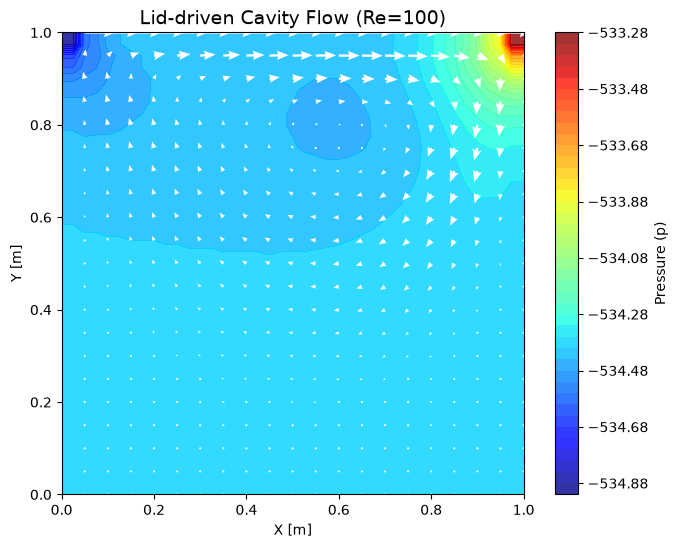

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("データの読み込み中...")
# 1. CSVデータの読み込み
df = pd.read_csv("../data/result.csv")

# 2. 格子サイズ (NX, NY) の自動判定
# xとyのユニークな（重複しない）値の数を数えることで、C++側のNX, NYを自動取得します
NX = len(df['x'].unique())
NY = len(df['y'].unique())

# 3. 1次元データを2次元配列 (メッシュ) に変換
# C++コードでは yを外側、xを内側のループで出力したため、(NY, NX) の順番で変形します
X = df['x'].values.reshape(NY, NX)
Y = df['y'].values.reshape(NY, NX)
U = df['u'].values.reshape(NY, NX)
V = df['v'].values.reshape(NY, NX)
P = df['p'].values.reshape(NY, NX)

# 4. 可視化の描画設定
plt.figure(figsize=(8, 6))

# --- A: 圧力のカラーマップ (等高線塗りつぶし) ---
# cmap='jet'（青〜赤）や 'viridis'（紫〜黄）が流体ではよく使われます
contour = plt.contourf(X, Y, P, alpha=0.8, cmap='jet', levels=50)
plt.colorbar(contour, label='Pressure (p)')

# --- B: 速度ベクトルの矢印 (Quiver) ---
# 41x41の矢印をすべて描くと真っ黒に潰れてしまうため、2つおきに間引いて(skip)描画します
skip = (slice(None, None, 2), slice(None, None, 2))
plt.quiver(X[skip], Y[skip], U[skip], V[skip],
           color='white',       # 背景がカラフルなので矢印は白
           scale=15,            # 矢印の長さを調整 (小さいほど長くなる)
           width=0.005,         # 矢印の太さ
           headwidth=4)         # 矢印の頭の大きさ

# --- C: 見栄えの調整 ---
plt.title("Lid-driven Cavity Flow (Re=100)", fontsize=14)
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)
plt.gca().set_aspect('equal') # 縦横比を1:1に固定

# 5. 画像として保存して画面に表示
plt.savefig("cavity_result.png", dpi=300, bbox_inches='tight')
print("可視化完了！ 'cavity_result.png' として保存しました。")
plt.show()